# **Pandemic Prediction**

## **Load Data**

In [23]:
import pandas as pd
df = pd.read_csv("/content/Dataset/symbipredict_2022.csv")
df

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal Infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4956,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Vertigo
4957,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,Acne
4958,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Urinary Tract Infection
4959,0,1,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,0,0,0,Psoriasis


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

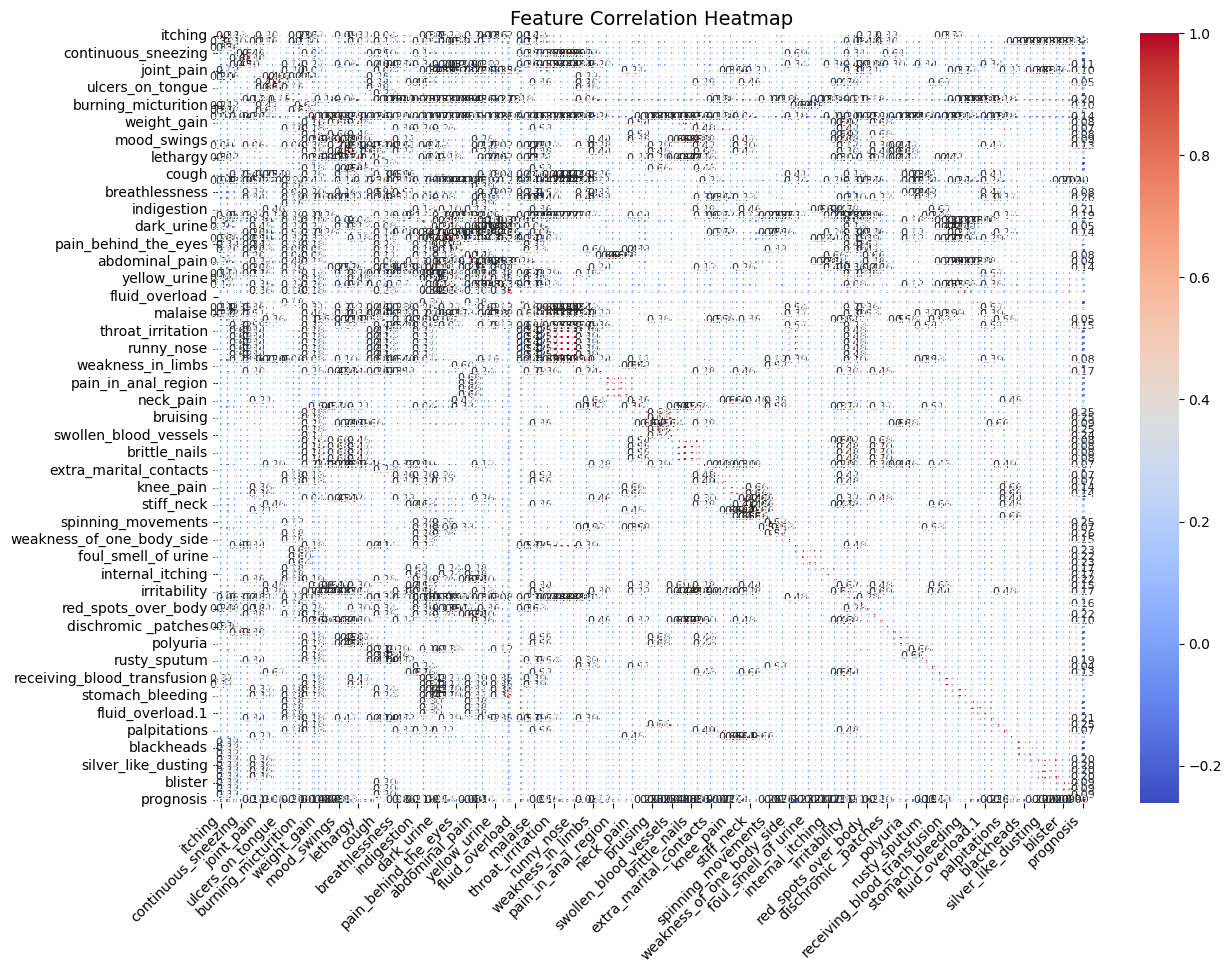

In [35]:
df_encoded = df.copy()
for col in df.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Compute the correlation matrix
corr_matrix = df_encoded.corr()

# Increase figure size for better readability
plt.figure(figsize=(14, 10))

# Use a diverging colormap and increase font size
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1, annot_kws={"size": 8})

# Titles and labels
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels
plt.yticks(rotation=0)  # Keep y-axis labels horizontal

plt.show()

### **Info on the dataset**

In [ ]:
print(df.head())
print(df.info())
print(df.describe())
print(df.size)


   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
0        1          1                     1                    0          0   
1        0          1                     1                    0          0   
2        1          0                     1                    0          0   
3        1          1                     0                    0          0   
4        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
0       0           0             0        0                 0  ...   
1       0           0             0        0                 0  ...   
2       0           0             0        0                 0  ...   
3       0           0             0        0                 0  ...   
4       0           0             0        0                 0  ...   

   blackheads  scurring  skin_peeling  silver_like_dusting  \
0           0         0             

### **Check for null values**

In [ ]:
print(df.isnull().sum())
print(df.isna().sum())

itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64
itching                 0
skin_rash               0
nodal_skin_eruptions    0
continuous_sneezing     0
shivering               0
                       ..
inflammatory_nails      0
blister                 0
red_sore_around_nose    0
yellow_crust_ooze       0
prognosis               0
Length: 133, dtype: int64


### **Cleaning the data**

In [ ]:
df.shape

(4961, 133)

### **finding duplicates**

In [ ]:
duplicates = df[df.duplicated()]
print(f"Total number of duplicated rows: {duplicates.shape[0]}")
print(duplicates.head())


Total number of duplicated rows: 4657
   itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
5        0          1                     1                    0          0   
6        1          0                     1                    0          0   
7        1          1                     0                    0          0   
8        1          1                     1                    0          0   
9        1          1                     1                    0          0   

   chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
5       0           0             0        0                 0  ...   
6       0           0             0        0                 0  ...   
7       0           0             0        0                 0  ...   
8       0           0             0        0                 0  ...   
9       0           0             0        0                 0  ...   

   blackheads  scurring  skin_peeling  silver_like_dusting  

### **Removing Duplicates and splitting x and y**

---



In [ ]:
df.drop_duplicates(inplace=True)
print(f"The dataset after duplicates are removed: {df.shape}")

x = df.drop("prognosis", axis=1)
y = df["prognosis"]

print(f"Shape of x before balancing: {x.shape}")
print(f"Shape of y before balancing: {y.shape}")

print(f"Class Distribution before RandomOverSampler: {y.value_counts()}")


The dataset after duplicates are removed: (304, 133)
Shape of x before balancing: (304, 132)
Shape of y before balancing: (304,)
Class Distribution before RandomOverSampler: prognosis
Hepatitis D                      10
Dengue                           10
Chickenpox                       10
Migraine                         10
Hepatitis B                       9
Hypoglycemia                      9
Common Cold                       9
Tuberculosis                      9
Hepatitis E                       9
Hepatitis A                       9
Typhoid                           9
Hyperthyroidism                   9
Jaundice                          9
Diabetes                          9
Pneumonia                         9
Varicose Veins                    8
Malaria                           8
Hypothyroidism                    8
Alcoholic Hepatitis               8
Chronic Cholestasis               8
Osteoarthritis                    7
Bronchial Asthma                  7
Vertigo                 

### **Balance the training data**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="not majority", random_state=100, k_neighbors=4)
x_resampled,y_resampled = smote.fit_resample(x,y)
print(f"Shape of x after smote: {x_resampled.shape}")
print(f"Shape of y after smote: {y_resampled.shape}")
print(f"Class Distribution after smote: {y_resampled.value_counts()}")

Shape of x after smote: (410, 132)
Shape of y after smote: (410,)
Class Distribution after smote: prognosis
Fungal Infection                 10
Hepatitis C                      10
Hepatitis E                      10
Alcoholic Hepatitis              10
Tuberculosis                     10
Common Cold                      10
Pneumonia                        10
Dimorphic Hemmorhoids (piles)    10
Heart Attack                     10
Varicose Veins                   10
Hypothyroidism                   10
Hyperthyroidism                  10
Hypoglycemia                     10
Osteoarthritis                   10
Arthritis                        10
Vertigo                          10
Acne                             10
Urinary Tract Infection          10
Psoriasis                        10
Hepatitis D                      10
Hepatitis B                      10
Allergy                          10
Hepatitis A                      10
GERD                             10
Chronic Cholestasis         

### **Data Splitting**


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_resampled, y_resampled, test_size= 0.2, random_state=42, stratify=y_resampled)

print(f"Shape of x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}, y_test: {y_test.shape}")

Shape of x_train: (328, 132), y_train: (328,)
Shape of x_test: (82, 132), y_test: (82,)


### **Check class Distribution**

In [ ]:
from collections import Counter

print("Distribution in y_train:", Counter(y_train))
print("Distribution in y_test:", Counter(y_test))

Distribution in y_train: Counter({'Dengue': 8, 'Impetigo': 8, 'Paralysis (brain hemorrhage)': 8, 'Vertigo': 8, 'Common Cold': 8, 'Dimorphic Hemmorhoids (piles)': 8, 'Hepatitis E': 8, 'Gastroenteritis': 8, 'Jaundice': 8, 'Pneumonia': 8, 'Psoriasis': 8, 'Osteoarthritis': 8, 'Migraine': 8, 'Chronic Cholestasis': 8, 'Hepatitis B': 8, 'Acne': 8, 'Chickenpox': 8, 'Cervical Spondylosis': 8, 'Typhoid': 8, 'GERD': 8, 'Allergy': 8, 'Varicose Veins': 8, 'Hepatitis D': 8, 'Peptic Ulcer Disease': 8, 'Bronchial Asthma': 8, 'Hypothyroidism': 8, 'Drug Reaction': 8, 'Hepatitis C': 8, 'Tuberculosis': 8, 'AIDS': 8, 'Hyperthyroidism': 8, 'Diabetes ': 8, 'Hypertension ': 8, 'Urinary Tract Infection': 8, 'Arthritis': 8, 'Heart Attack': 8, 'Malaria': 8, 'Hypoglycemia': 8, 'Hepatitis A': 8, 'Fungal Infection': 8, 'Alcoholic Hepatitis': 8})
Distribution in y_test: Counter({'Typhoid': 2, 'Gastroenteritis': 2, 'Impetigo': 2, 'Bronchial Asthma': 2, 'Pneumonia': 2, 'Allergy': 2, 'Hepatitis B': 2, 'Migraine': 2, 'A

## **Model Building**

### **RandomForestClassifier**

### **Training the model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=40, random_state=42, min_samples_split=8, min_samples_leaf=6, max_depth=8, max_features="sqrt", class_weight="balanced")
model.fit(x_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=6,
                       min_samples_split=8, n_estimators=40, random_state=42)

### **Applying model to make prediction**



In [ ]:
y_test_pred = model.predict(x_test)

## **Evaluate the model**

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    'n_estimators': [30,40,50],
    'max_depth': [7,8,9],
    'min_samples_split': [6,8,10],
    'min_samples_leaf': [4,6,8],
    'max_features': ['sqrt', 'log2']
}

random_forest = RandomForestClassifier(random_state=42, class_weight="balanced")
grid_search = GridSearchCV(estimator=random_forest,param_grid=param_grid, cv=5,scoring="f1_macro")
grid_search.fit(x_train, y_train)

print("Best Parameters:",grid_search.best_params_)

Best_model = grid_search.best_estimator_
y_test_pred = Best_model.predict(x_test)
y_train_pred = Best_model.predict(x_train)

test_accuracy = accuracy_score(y_test,y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")
train_accuracy = accuracy_score(y_train,y_train_pred)
print(f"Train Accuracy: {train_accuracy:.2f}")
classification_report = classification_report(y_test,y_test_pred)
print("Classification Report:\n",classification_report)


Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 50}
Test Accuracy: 1.00
Train Accuracy: 1.00
Classification Report:
                                precision    recall  f1-score   support

                         AIDS       1.00      1.00      1.00         2
                         Acne       1.00      1.00      1.00         2
          Alcoholic Hepatitis       1.00      1.00      1.00         2
                      Allergy       1.00      1.00      1.00         2
                    Arthritis       1.00      1.00      1.00         2
             Bronchial Asthma       1.00      1.00      1.00         2
         Cervical Spondylosis       1.00      1.00      1.00         2
                   Chickenpox       1.00      1.00      1.00         2
          Chronic Cholestasis       1.00      1.00      1.00         2
                  Common Cold       1.00      1.00      1.00         2
                       Dengu

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



TP = np.diag(cm)  # True Positives are the diagonal elements
FP = cm.sum(axis=0) - TP  # False Positives: sum of column - TP
FN = cm.sum(axis=1) - TP  # False Negatives: sum of row - TP
TN = cm.sum() - (TP + FP + FN)  # True Negatives: total sum - (TP, FP, FN)

# Print results per class
for i, class_name in enumerate(Best_model.classes_):
    print(f"Class: {class_name}")
    print(f"  True Positives: {TP[i]}")
    print(f"  False Positives: {FP[i]}")
    print(f"  False Negatives: {FN[i]}")
    print(f"  True Negatives: {TN[i]}")
    print()


Class: AIDS
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Acne
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Alcoholic Hepatitis
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Allergy
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Arthritis
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Bronchial Asthma
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Cervical Spondylosis
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Chickenpox
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Chronic Cholestasis
  True Positives: 2
  False Positives: 0
  False Negatives: 0
  True Negatives: 80

Class: Common Cold
  True Positives: 2
  False Positives: 0
  Fa

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(Best_model, x, y, cv=5, scoring="accuracy")

# Print cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation accuracy:", cv_scores.mean())

Cross-validation scores: [1.         0.93442623 0.95081967 0.93442623 0.96666667]
Mean cross-validation accuracy: 0.9572677595628415
Cross-validation scores: [1.         0.93442623 0.95081967 0.93442623 0.96666667]
Mean cross-validation accuracy: 0.9572677595628415


In [ ]:
# Check for duplicates between training and test sets
train_test_duplicates = set(x_train.index).intersection(set(x_test.index))
print("Number of duplicates between training and test sets:", len(train_test_duplicates))

Number of duplicates between training and test sets: 0


In [ ]:
# Train the final model on the entire training set
Best_model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=9, min_samples_leaf=4,
                       min_samples_split=6, n_estimators=50, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Evaluate on the test set
y_test_pred = Best_model.predict(x_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print(classification_report(y_test, y_test_pred, zero_division=0))

Test Accuracy: 1.00
                               precision    recall  f1-score   support

                         AIDS       1.00      1.00      1.00         2
                         Acne       1.00      1.00      1.00         2
          Alcoholic Hepatitis       1.00      1.00      1.00         2
                      Allergy       1.00      1.00      1.00         2
                    Arthritis       1.00      1.00      1.00         2
             Bronchial Asthma       1.00      1.00      1.00         2
         Cervical Spondylosis       1.00      1.00      1.00         2
                   Chickenpox       1.00      1.00      1.00         2
          Chronic Cholestasis       1.00      1.00      1.00         2
                  Common Cold       1.00      1.00      1.00         2
                       Dengue       1.00      1.00      1.00         2
                    Diabetes        1.00      1.00      1.00         2
Dimorphic Hemmorhoids (piles)       1.00      1.00      

In [ ]:
print("Classes predicted by the model:", set(y_test_pred))
print("Classes in test set:", set(y_test))
print(y_test_pred.shape)
print(y_test.shape)

Classes predicted by the model: {'Drug Reaction', 'Peptic Ulcer Disease', 'Hypothyroidism', 'Gastroenteritis', 'Allergy', 'Common Cold', 'Paralysis (brain hemorrhage)', 'Hepatitis C', 'Bronchial Asthma', 'Chickenpox', 'Hepatitis E', 'Vertigo', 'Varicose Veins', 'Chronic Cholestasis', 'Hypertension ', 'Pneumonia', 'Hypoglycemia', 'Hepatitis A', 'Migraine', 'GERD', 'Tuberculosis', 'Heart Attack', 'Psoriasis', 'Typhoid', 'Hyperthyroidism', 'Cervical Spondylosis', 'Acne', 'Diabetes ', 'Dimorphic Hemmorhoids (piles)', 'Jaundice', 'Osteoarthritis', 'Hepatitis B', 'Urinary Tract Infection', 'Arthritis', 'Hepatitis D', 'AIDS', 'Alcoholic Hepatitis', 'Dengue', 'Fungal Infection', 'Malaria', 'Impetigo'}
Classes in test set: {'Drug Reaction', 'Peptic Ulcer Disease', 'Hypothyroidism', 'Gastroenteritis', 'Allergy', 'Common Cold', 'Paralysis (brain hemorrhage)', 'Hepatitis C', 'Bronchial Asthma', 'Chickenpox', 'Hepatitis E', 'Vertigo', 'Varicose Veins', 'Chronic Cholestasis', 'Hypertension ', 'Pneum

In [ ]:
import joblib

model_filename ="Best_random_forest_model.pkl"
joblib.dump(Best_model, model_filename)

from google.colab import files
files.download(model_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
# Compute the correlation matrix

corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Titles and labels
plt.title("Feature Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'Fungal Infection'